In [70]:
import cv2
import os
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Utility Functions

## Extract Frames (for SmartPhone Videos)

In [3]:
def extract_frames(video_path, output_root="frames", frame_skip=1):
    """
    video_path: path to video file
    output_root: root folder to store frames
    frame_skip: save every nth frame
    """

    # Get video name (without extension)
    video_name = os.path.splitext(os.path.basename(video_path))[0]

    # Create output directory for this video
    output_dir = os.path.join(output_root, video_name)
    os.makedirs(output_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Cannot open video")
        return

    frame_count = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Save every nth frame
        if frame_count % frame_skip == 0:
            filename = os.path.join(output_dir, f"frame_{saved_count:05d}.jpg")
            cv2.imwrite(filename, frame)
            saved_count += 1

        frame_count += 1

    cap.release()

    print(f"Saved {saved_count} frames to {output_dir}")

### Driver Code

In [173]:
vid_path = './input_videos/main_building_1.mp4'
# vid_path = './input_videos/mountains_1.mp4'
# vid_path = './input_videos/mountains_2.mp4'
output_dir = './output_frames'
extract_frames(vid_path, output_dir, frame_skip = 50)

Saved 10 frames to ./output_frames/main_building_1


## Loading Images (and Optionally re-sizing them)

In [48]:
def load_and_resize_images(folder_path, scale=0.5, max_dim=None):
    """
    scale: resize factor (e.g., 0.5)
    max_dim: alternatively limit max dimension
    """

    extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG']
    image_paths = []
    
    for ext in extensions:
        image_paths.extend(glob(os.path.join(folder_path, ext)))
    image_paths = sorted(image_paths)
    
    images = []

    for path in image_paths:
        img = cv2.imread(path)
        h, w = img.shape[:2]

        if max_dim is not None:
            scale_factor = max_dim / max(h, w)
        else:
            scale_factor = scale

        if scale_factor < 1.0:
            new_w = int(w * scale_factor)
            new_h = int(h * scale_factor)

            img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
        images.append(img)
    return images, image_paths

# Feature Extraction (SIFT)

In [6]:
def extract_features(images):
    """
    Extract SIFT features from input image(s).
    images: list of images (loaded from the folder). (np.ndarray)

    returns: SIFT keypoints and descriptors
    """
    sift = cv2.SIFT_create()

    keypoints, descriptors = [], []

    for i, img in enumerate(images):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        kp, desc = sift.detectAndCompute(gray, None)

        keypoints.append(kp)
        descriptors.append(desc)

        print(f"[INFO] Image {i}: {len(kp)} keypoints")

    return keypoints, descriptors

# Feature Matching

In [7]:
def match_features(desc1, desc2, ratio=0.75):
    """
    Take two SIFT descriptors for images and provide the best list of good matches between them.
    desc1, desc2: SIFT descriptors of two images (np.Ndarray)

    returns: List of "good" matches between two SIFT image descriptors.
    """
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(desc1, desc2, k=2)

    good = []
    for m, n in matches:
        # We want the best match to be better than the second best by at least some extent (scale factor)
        if m.distance < ratio * n.distance: 
            good.append(m)
            
    return good

## Getting Matches across all Images (Consecutive)

In [8]:
def get_all_matches(descriptors, verbose = False):
    matches_all = []

    for i in range(len(descriptors) - 1):
        matches = match_features(descriptors[i], descriptors[i+1])
        if verbose:
            print(f"[INFO] Pair {i}-{i+1}: {len(matches)} correspondences")
        matches_all.append(matches)

    return matches_all

## Getting the Matched Points

In [9]:
def get_matched_points(kp1, kp2, matches):
    """
    Provides with the keypoints in the two images for the given set of matches between them
    desc1, desc2: SIFT descriptors of two images (np.Ndarray)

    returns: List of keypoints in the two images for the "good" matches 
             between two SIFT image descriptors.
    """
    pts1, pts2 = [], []

    for m in matches:
        pts1.append(kp1[m.queryIdx].pt) # Index in the first set of keypoints
        pts2.append(kp2[m.trainIdx].pt) # Index in the second set of keypoints

    return np.array(pts1), np.array(pts2)

# Point Normalization and Homography Estimation

## Point Normalization

In [10]:
def normalize_points(pts):
    """
    Normalize points so that:
    - centroid = (0, 0)
    - mean distance from origin = sqrt(2)
    return : Array of normalized points (ndarray), Transformation Matrix (3x3)
    """

    centroid = np.mean(pts, axis=0)
    pts_shifted = pts - centroid

    dists = np.sqrt(np.sum(pts_shifted**2, axis=1))
    mean_dist = np.mean(dists)

    scale = np.sqrt(2) / mean_dist

    # 3x3 transformation matrix
    T = np.array([
        [scale, 0, -scale * centroid[0]],
        [0, scale, -scale * centroid[1]],
        [0, 0, 1]
    ])

    # Convert to homogeneous
    pts_h = np.hstack([pts, np.ones((pts.shape[0], 1))])

    # Apply transformation (LEFT multiplication)
    pts_norm_h = (T @ pts_h.T).T

    # Convert back to Cartesian
    pts_norm = pts_norm_h[:, :2] / pts_norm_h[:, 2][:, None]

    return pts_norm, T

## Homography Estimation (with RANSAC)

In [11]:
def compute_homography_dlt(pts1, pts2):
    pts1, T1 = normalize_points(pts1)
    pts2, T2 = normalize_points(pts2)

    A = []

    for (x, y), (xp, yp) in zip(pts1, pts2):
        A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp])
        A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp])

    A = np.array(A)

    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3) # Reshape the vector into the homography matrix.

    H = np.linalg.inv(T2) @ H @ T1
    return H / H[2, 2] # Fixing the scale by keeping h9 = 1.

In [12]:
################### UNDERSTAND DIFFERENCE BETWEEN THIS AND THE BELOW FUNCTION ###################
def ransac_homography(pts1, pts2, iters=1000, thresh=3):
    """
    Robust RANSAC for homography estimation.

    pts1, pts2 : (N, 2) arrays of corresponding points
    iters      : number of RANSAC iterations
    thresh     : inlier threshold in pixels (reprojection error)
    eps        : small value to avoid division by zero

    Returns:
        best_H        : (3, 3) homography
        best_mask     : (N,) boolean mask of inliers
    """
    
    best_H = None
    max_inliers = 0
    best_mask = None

    N = pts1.shape[0]

    for _ in range(iters):
        # Select 4 correspondences randomly, in order to estimate the Homography.
        idx = np.random.choice(N, 4, replace=False)

        try:
            # Estimate homography
            H = compute_homography_dlt(pts1[idx], pts2[idx])
        except:
            continue

        pts1_h = np.hstack([pts1, np.ones((N, 1))]) # Homogeneous coordinates
        proj = (H @ pts1_h.T).T  # Apply the estimated Homography.
        proj = proj[:, :2] / proj[:, 2][:, None] # Convert Back to Cartesian.

        # Evaluate all correspondences
        error = np.linalg.norm(pts2 - proj, axis=1) # Re-projection Error (With the estimated homography)
        mask = error < thresh # Tells which points have been used for Homography estimation.
        
        # Count inliers and save the best Homography
        if np.sum(mask) > max_inliers:
            best_H = H
            max_inliers = np.sum(mask)
            best_mask = mask

    return best_H, best_mask

In [13]:
def is_degenerate(pts, tol=1e-6):
    """
    Checks if a set of 4 points is nearly collinear.
    Uses area of triangles formed by triplets.
    """
    if pts.shape[0] < 4:
        return True

    # Compute areas of triangles (p0, p1, p2), etc.
    def area(a, b, c):
        return 0.5 * np.abs(
            a[0]*(b[1]-c[1]) +
            b[0]*(c[1]-a[1]) +
            c[0]*(a[1]-b[1])
        )

    p = pts
    areas = [
        area(p[0], p[1], p[2]),
        area(p[0], p[1], p[3]),
        area(p[0], p[2], p[3]),
        area(p[1], p[2], p[3]),
    ]

    return max(areas) < tol

In [14]:
def ransac_homography(pts1, pts2, iters=1000, thresh=3.0, eps=1e-8):
    """
    Robust RANSAC for homography estimation.

    pts1, pts2 : (N, 2) arrays of corresponding points
    iters      : number of RANSAC iterations
    thresh     : inlier threshold in pixels (reprojection error)
    eps        : small value to avoid division by zero

    Returns:
        best_H        : (3, 3) homography
        best_mask     : (N,) boolean mask of inliers
    """

    best_H = None
    best_mask = None
    max_inliers = 0

    N = pts1.shape[0]
    if N < 4:
        return None, None

    # Precompute homogeneous coordinates for efficiency
    pts1_h = np.hstack([pts1, np.ones((N, 1))])  # (N, 3)

    for _ in range(iters):
        # 1) Sample minimal set (4 correspondences)
        idx = np.random.choice(N, 4, replace=False)

        # Reject degenerate configurations (e.g., nearly collinear points)
        if is_degenerate(pts1[idx]) or is_degenerate(pts2[idx]):
            continue

        # 2) Estimate homography from minimal sample
        try:
            H = compute_homography_dlt(pts1[idx], pts2[idx])
        except Exception:
            continue

        if H is None or not np.all(np.isfinite(H)):
            continue

        # 3) Project all pts1 using H (homogeneous)
        proj_h = (H @ pts1_h.T).T  # (N, 3)

        # 4) Safe normalization to Cartesian coordinates
        w = proj_h[:, 2]

        # Avoid division by very small numbers
        valid = np.abs(w) > eps

        # Initialize projected points with NaNs (invalid by default)
        proj = np.full((N, 2), np.nan, dtype=np.float64)

        # Only normalize valid points
        proj[valid] = proj_h[valid, :2] / w[valid, None]

        # 5) Reprojection error (ignore invalid projections)
        # error_i = || x'_i - H x_i ||
        diff = pts2 - proj
        error = np.linalg.norm(diff, axis=1)

        # Mark invalid projections as outliers
        error[~valid] = np.inf

        # 6) Inlier mask
        mask = error < thresh
        num_inliers = np.sum(mask)

        # 7) Keep the best model
        if num_inliers > max_inliers:
            max_inliers = num_inliers
            best_H = H
            best_mask = mask

    # 8) Re-estimate H using all inliers (crucial refinement)
    if best_mask is not None and np.sum(best_mask) >= 4:
        try:
            best_H = compute_homography_dlt(pts1[best_mask], pts2[best_mask])
        except Exception:
            pass

    return best_H, best_mask

In [150]:
def ransac_homography_robust( pts1, pts2, iters=2000, thresh=3.0,
    eps=1e-8,
    lambda_penalty=0.1,
    min_spread=20,
    max_cond=1e4,
    use_symmetric_error=True
):
    """
    Improved RANSAC with:
    - Spatial spread check
    - Homography validation
    - Better scoring
    - Optional symmetric error
    """

    best_H = None
    best_mask = None
    best_score = -np.inf

    N = pts1.shape[0]
    if N < 4:
        return None, None

    pts1_h = np.hstack([pts1, np.ones((N, 1))])
    pts2_h = np.hstack([pts2, np.ones((N, 1))])

    for _ in range(iters):

        # 1. Sample 4 points
        idx = np.random.choice(N, 4, replace=False)

        # --- Degeneracy check ---
        if is_degenerate(pts1[idx]) or is_degenerate(pts2[idx]):
            continue

        # --- Spatial spread check ---
        if (np.std(pts1[idx][:, 0]) < min_spread or
            np.std(pts1[idx][:, 1]) < min_spread):
            continue

        try:
            H = compute_homography_dlt(pts1[idx], pts2[idx])
        except:
            continue

        if H is None or not np.all(np.isfinite(H)):
            continue

        # --- Homography sanity check ---
        det_H = np.linalg.det(H)
        cond_H = np.linalg.cond(H)

        if abs(det_H) < 1e-6 or abs(det_H) > 50:
            continue

        if cond_H > max_cond:
            continue

        # --- Forward projection ---
        proj_h = (H @ pts1_h.T).T
        w = proj_h[:, 2]

        valid = np.abs(w) > eps
        proj = np.full((N, 2), np.nan)

        proj[valid] = proj_h[valid, :2] / w[valid][:, None]

        error_fwd = np.linalg.norm(pts2 - proj, axis=1)
        error_fwd[~valid] = np.inf

        # --- Optional symmetric error ---
        if use_symmetric_error:
            try:
                H_inv = np.linalg.inv(H)

                proj2_h = (H_inv @ pts2_h.T).T
                w2 = proj2_h[:, 2]

                valid2 = np.abs(w2) > eps
                proj2 = np.full((N, 2), np.nan)

                proj2[valid2] = proj2_h[valid2, :2] / w2[valid2][:, None]

                error_bwd = np.linalg.norm(pts1 - proj2, axis=1)
                error_bwd[~valid2] = np.inf

                error = error_fwd + error_bwd
            except:
                error = error_fwd
        else:
            error = error_fwd

        # --- Inliers ---
        mask = error < thresh
        num_inliers = np.sum(mask)

        if num_inliers < 4:
            continue

        mean_error = np.mean(error[mask])

        # --- Scoring ---
        score = num_inliers - lambda_penalty * mean_error

        if score > best_score:
            best_score = score
            best_H = H
            best_mask = mask

    # --- Final refinement ---
    if best_mask is not None and np.sum(best_mask) >= 4:
        try:
            best_H = compute_homography_dlt(
                pts1[best_mask],
                pts2[best_mask]
            )
        except:
            pass

    return best_H, best_mask

## Getting the Frame of Reference (Global Homography)

In [15]:
def compute_global_homographies(pairwise_H, ref_idx):
    n = len(pairwise_H) + 1
    H_global = [None] * n

    H_global[ref_idx] = np.eye(3) # The Homography of the reference index must be I.

    for i in range(ref_idx, n-1):
        H_global[i+1] = H_global[i] @ np.linalg.inv(pairwise_H[i])

    for i in range(ref_idx-1, -1, -1):
        H_global[i] = H_global[i+1] @ pairwise_H[i]

    return H_global

# Stitching and Warping Images

In [16]:
def get_canvas_bounds(images, Hs):
    corners_all = []

    for img, H in zip(images, Hs):
        h, w = img.shape[:2]
        corners = np.array([[0,0],[w,0],[w,h],[0,h]])

        corners_h = np.hstack([corners, np.ones((4,1))])
        warped = (H @ corners_h.T).T
        warped = warped[:, :2] / warped[:, 2][:, None]

        corners_all.append(warped)

    corners_all = np.vstack(corners_all)
    
    return np.min(corners_all, axis=0), np.max(corners_all, axis=0)
    # return corners_all

In [17]:
def warp_and_stitch(images, Hs):
    (xmin, ymin), (xmax, ymax) = get_canvas_bounds(images, Hs)

    T = np.array([
        [1, 0, -xmin],
        [0, 1, -ymin],
        [0, 0, 1]
    ])

    width = int(xmax - xmin)
    height = int(ymax - ymin)

    canvas = np.zeros((height, width, 3), dtype=np.float32)
    weight = np.zeros((height, width), dtype=np.float32)

    for i, (img, H) in enumerate(zip(images, Hs)):
        print(f"[INFO] Warping image {i}")

        warped = cv2.warpPerspective(img, T @ H, (width, height))

        mask = (np.sum(warped, axis=2) > 0).astype(np.float32)
        mask3 = np.stack([mask]*3, axis=2)

        canvas += warped.astype(np.float32) * mask3
        weight += mask

    weight[weight == 0] = 1
    canvas /= weight[:, :, None]

    return canvas.astype(np.uint8)

# Visualization

In [18]:
def display_panorama(panorama, save_path = None):  
    plt.figure(figsize=(12,6))
    plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Panorama")
    plt.show()
    if save_path:
        cv2.imwrite(save_path, panorama)

In [28]:
def plot_comparison(img1, img2,title1 = None, title2 = None, save_path=None):
    """
    Displays two images side-by-side for comparison.

    Parameters:
        img1: First image (All images case)
        img2: Second image (Reduced set case)
        save_path: Path to save the figure (optional)
    """

    # Convert BGR (OpenCV) → RGB (Matplotlib)
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))

    # First subplot
    axes[0].imshow(img1_rgb)
    if title1 is None:
        axes[0].set_title("All images")
    else:
        axes[0].set_title(title1)
    axes[0].axis('off')

    # Second subplot
    axes[1].imshow(img2_rgb)
    if title2 is None:
        axes[1].set_title("Reduced set")
    else:
        axes[1].set_title(title2)
    axes[1].axis('off')

    plt.tight_layout()

    # Save if path provided
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"[INFO] Saved comparison to {save_path}")

    plt.show()

# Driver Code


 ############### Feature Extraction ############### 

[INFO] Image 0: 3993 keypoints
[INFO] Image 1: 4084 keypoints
[INFO] Image 2: 3558 keypoints
[INFO] Image 3: 3628 keypoints
[INFO] Image 4: 3203 keypoints
[INFO] Image 5: 2857 keypoints
[INFO] Image 6: 2808 keypoints

 ############### Feature Matching ############### 

[INFO] Pair 0-1: 295 correspondences
[INFO] Pair 1-2: 257 correspondences
[INFO] Pair 2-3: 405 correspondences
[INFO] Pair 3-4: 338 correspondences
[INFO] Pair 4-5: 503 correspondences
[INFO] Pair 5-6: 705 correspondences


 ############### Image Warping ############### 

[INFO] Warping image 0
[INFO] Warping image 1
[INFO] Warping image 2
[INFO] Warping image 3
[INFO] Warping image 4
[INFO] Warping image 5


 ############### Display Mosaic ############### 



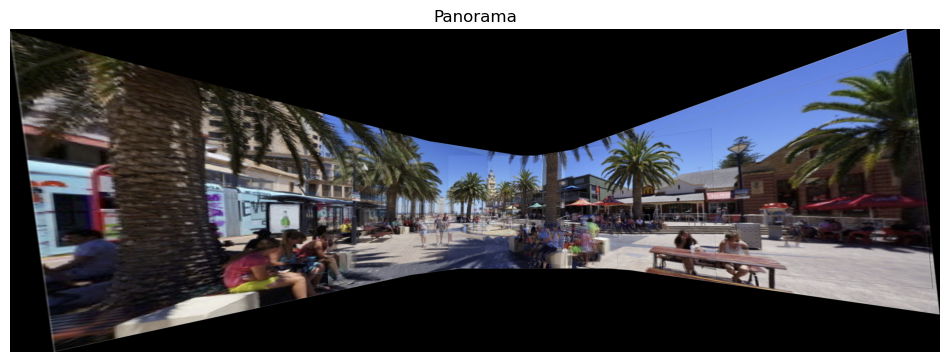

In [230]:
img_name = "apap-train"
condition = "all"
img_path = './output_frames/APAP-train'

save_path = f'./Report/{img_name}-{condition}.jpg'
image, image_paths = load_and_resize_images(img_path,scale = 1)

print("\n","#"*15, "Feature Extraction", "#"*15,"\n")
keypoints, descriptors = extract_features(image)


print("\n","#"*15, "Feature Matching", "#"*15,"\n")
matches = get_all_matches(descriptors, verbose = True) # Finds match for consecutive pairs of images.


# Homographies
pairwise_H = []

for i in range(len(matches)):
    pts1, pts2 = get_matched_points(keypoints[i], keypoints[i+1], matches[i])

    if len(pts1) < 4:
        pairwise_H.append(np.eye(3))
        continue

    H, mask = ransac_homography(pts1, pts2, iters = 2000, thresh = 2.0)
    # H, mask = ransac_homography_robust(pts1, pts2)
    pairwise_H.append(H)

# Reference frame
ref_idx = len(image) // 2

# Global homographies
H_global = compute_global_homographies(pairwise_H, ref_idx)

print()
print("\n","#"*15, "Image Warping", "#"*15,"\n")
# panorama = warp_and_stitch(image, H_global)
panorama = warp_and_stitch(image[1:], H_global[1:])

print()
print("\n","#"*15, "Display Mosaic", "#"*15,"\n")
display_panorama(panorama, save_path = save_path)

[INFO] Saved comparison to ./Report/dataset-3-comparison.jpg


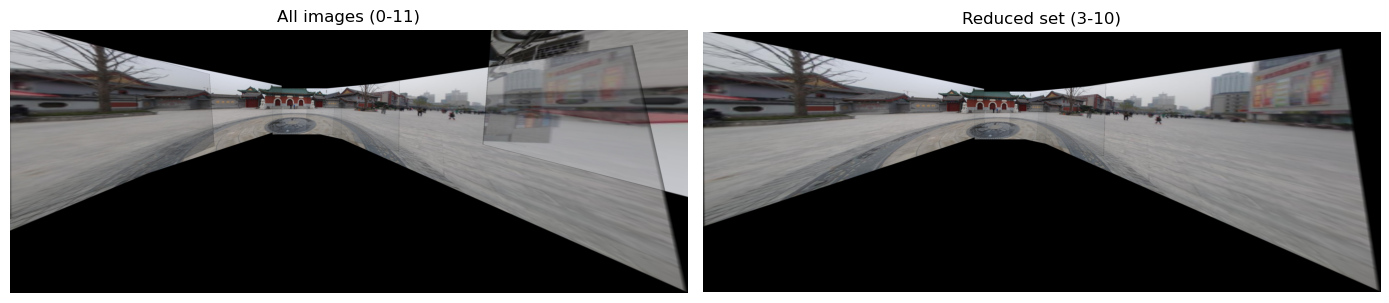

In [221]:
img1 = f'./Report/{img_name}-all.jpg'
img2 = f'./Report/{img_name}-reduced.jpg'
scale_factor = 0.75
image_paths = [img1, img2]
save_path = f'./Report/{img_name}-comparison.jpg'
images = []

for path in image_paths:
    img = cv2.imread(path)
    h, w = img.shape[:2]

    if scale_factor < 1.0:
        new_w = int(w * scale_factor)
        new_h = int(h * scale_factor)

        img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    images.append(img)


plot_comparison(images[0], images[1],title1 = "All images (0-11)"
                ,title2 = "Reduced set (3-10)" ,save_path =  save_path)

# Reporting and Analysis

## Re-projection Error

In [105]:
def analyze_pairwise_homographies(matches, keypoints, homographies):
    records = []

    for i in range(len(matches)):
        pts1, pts2 = get_matched_points(
            keypoints[i],
            keypoints[i+1],
            matches[i]
        )

        H = homographies[i]

        if H is None or len(pts1) < 4:
            continue

        # Project points
        pts1_h = np.hstack([pts1, np.ones((pts1.shape[0], 1))])
        proj = (H @ pts1_h.T).T

        # Safe normalization
        w = proj[:, 2]
        valid = np.abs(w) > 1e-8

        proj_cart = np.zeros_like(pts2)
        proj_cart[valid] = proj[valid, :2] / w[valid][:, None]

        error = np.linalg.norm(pts2 - proj_cart, axis=1)
        error[~valid] = np.inf

        records.append({
            "pair": f"{i}-{i+1}",
            "num_matches": len(pts1),
            "mean_error": np.mean(error[np.isfinite(error)]),
            "max_error": np.max(error[np.isfinite(error)]),
            "det_H": np.linalg.det(H)
        })

    df = pd.DataFrame(records)
    return df

In [64]:
def display_stats_table(df):
    print("\n===== Pairwise Homography Analysis =====\n")
    print(df.to_string(index=False))

In [106]:
def plot_errors(df, save_path = None):
    plt.figure(figsize=(8, 4))
    plt.plot(df["mean_error"], marker='o')

    plt.xticks(range(len(df)), df["pair"], rotation=45)
    plt.xlabel("Image Pair")
    plt.ylabel("Mean Reprojection Error")
    plt.title("Error across Image Pairs")
    plt.grid()

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi = 300)
    plt.show()

In [222]:
stats = analyze_pairwise_homographies(matches,keypoints, pairwise_H)
display_stats_table(stats)


===== Pairwise Homography Analysis =====

pair  num_matches  mean_error  max_error     det_H
 0-1           73   36.606191 660.025468  5.320915
 1-2           46  147.597587 899.795903 69.068874
 2-3          108   21.015063 420.477259  3.447582
 3-4          105   15.693065 401.876800  3.560062


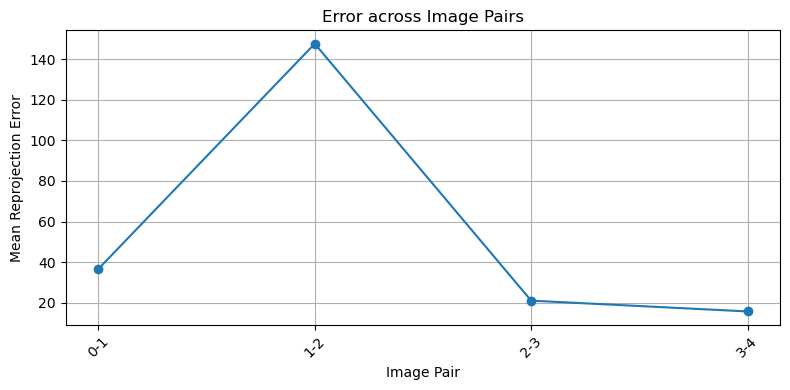

In [223]:
save_path = f'./Report/{img_name}-errors.png'
plot_errors(stats, save_path)

## Feature Extraction and Matching Analysis

In [85]:
def visualize_keypoints(image, keypoints, max_points=200):
    img_kp = cv2.drawKeypoints(
        image,
        keypoints[:max_points],
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
    plt.title("Detected Keypoints")
    plt.axis('off')
    plt.show()

In [86]:
def visualize_matches(img1, kp1, img2, kp2, matches, max_matches=50):
    img_match = cv2.drawMatches(
        img1, kp1,
        img2, kp2,
        matches[:max_matches],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(img_match, cv2.COLOR_BGR2RGB))
    plt.title(f"Top {max_matches} Matches")
    plt.axis('off')
    plt.show()

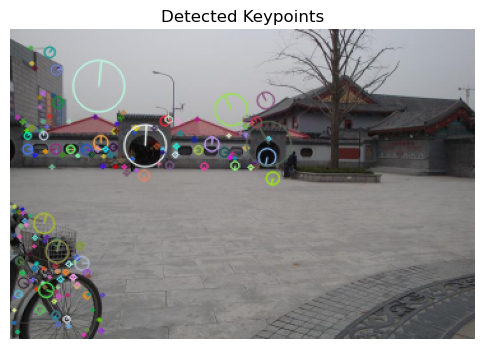

In [110]:
visualize_keypoints(image[0], keypoints[0])

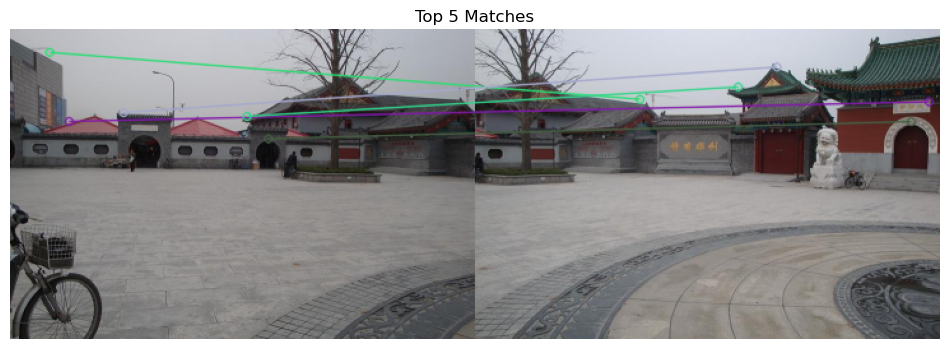

In [113]:
i = 0
visualize_matches(
    image[i], keypoints[i],
    image[i+1], keypoints[i+1],
    matches[i],
    max_matches = 5
)

## Analysing RANSAC matches

In [121]:
def visualize_inlier_matches(img1, kp1, img2, kp2, matches, inlier_mask, max_matches=100):
    """
    Visualize only RANSAC inlier matches

    matches: list of cv2.DMatch
    inlier_mask: boolean array of size len(matches)
    """

    # Filter matches using mask
    inlier_matches = [m for m, inlier in zip(matches, inlier_mask) if inlier]

    # Limit number for visualization
    inlier_matches = inlier_matches[:max_matches]

    # Draw matches
    img_match = cv2.drawMatches(
        img1, kp1,
        img2, kp2,
        inlier_matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img_match, cv2.COLOR_BGR2RGB))
    plt.title(f"Inlier Matches ({len(inlier_matches)})")
    plt.axis('off')
    plt.show()

In [189]:
def compare_matches_vs_inliers(img1, kp1, img2, kp2, matches, inlier_mask, max_matches=100, save_path = None):
    """
    Show ALL matches vs INLIERS side-by-side
    """

    # All matches
    img_all = cv2.drawMatches(
        img1, kp1,
        img2, kp2,
        matches[:max_matches],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    # Inliers only
    inlier_matches = [m for m, inlier in zip(matches, inlier_mask) if inlier]
    inlier_matches = inlier_matches[:max_matches]

    img_inliers = cv2.drawMatches(
        img1, kp1,
        img2, kp2,
        inlier_matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    # Plot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(cv2.cvtColor(img_all, cv2.COLOR_BGR2RGB))
    axes[0].set_title("All Matches")
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(img_inliers, cv2.COLOR_BGR2RGB))
    axes[1].set_title("RANSAC Inliers")
    axes[1].axis('off')

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi = 300)
    plt.show()

Inlier Ratio:  0.5


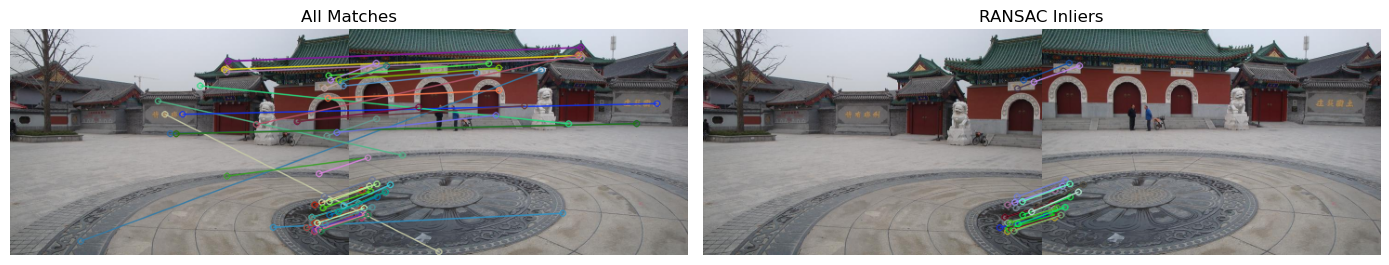

In [225]:
save_path = f"./Report/{img_name}-feat-match.png"
i = 1 # choose any pair

pts1, pts2 = get_matched_points(
    keypoints[i],
    keypoints[i+1],
    matches[i]
)

H, inlier_mask = ransac_homography(pts1, pts2, thresh = 2.0)
inlier_ratio = np.sum(inlier_mask) / len(inlier_mask)
print("Inlier Ratio: ", inlier_ratio)

# Visualize
compare_matches_vs_inliers(
    image[i], keypoints[i],
    image[i+1], keypoints[i+1],
    matches[i],
    inlier_mask,
    save_path = save_path
)

In [137]:
def plot_points_distribution(pts, title=""):
    import matplotlib.pyplot as plt

    plt.scatter(pts[:,0], pts[:,1], s=5)
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.show()

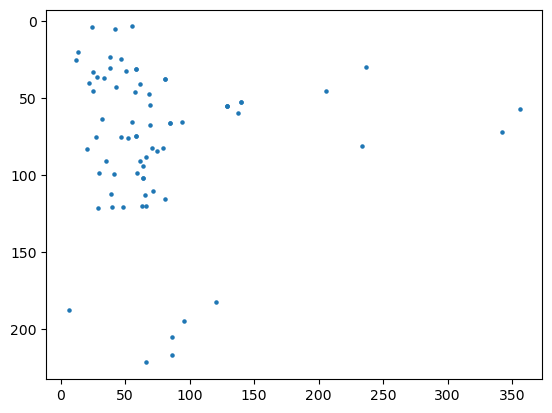

In [145]:
plot_points_distribution(pts2)